# Notebook 04 — Contact Resistance Audit

## Goal

This notebook investigates why the Tier-0 perturbation `Contact resistance [Ohm] = 0.005` produced no observable response in the previous HPPC sanity scan.

The purpose is to determine whether the contact resistance parameter is inactive under the current PyBaMM DFN setup, hidden by model options, or not visible through the selected observable extraction chain.

## Scientific context

In the aging-bridge project, contact resistance growth is intended to represent an ohmic degradation pathway.

Expected observable fingerprint:

DFN-level contact resistance increase  
→ larger instantaneous voltage drop during current pulse  
→ increased short-window Ri  
→ minimal change in relaxation time constants

However, Notebook 03 showed no observable change in Ri, voltage response, or relaxation descriptors when `Contact resistance [Ohm]` was set to 5 mΩ.

This notebook audits that discrepancy before expanding the perturbation matrix.

## Workflow

1. Import packages and audit software versions and paths.
2. Inspect the Chen2020 contact resistance parameter.
3. Test whether changing `Contact resistance [Ohm]` modifies DFN voltage output.
4. Compare baseline and contact-resistance cases under identical HPPC conditions.
5. Check whether the model exposes a contact resistance-related voltage contribution.
6. Evaluate whether contact resistance requires a model option or alternative implementation.
7. Produce voltage/current overlay plots and Ri comparison tables.

## Expected outputs

- Contact resistance parameter audit table
- Baseline vs contact-resistance HPPC overlay
- CDEFG / Ri comparison
- Diagnostic conclusion on whether the parameter is active in the current DFN configuration

## Interpretation boundary

This notebook does not evaluate aging mechanisms broadly.

It only answers whether the current PyBaMM DFN configuration responds to `Contact resistance [Ohm]` as an ohmic perturbation.

If no response is observed, the conclusion must be stated as:

“Contact resistance is not observable under the current model configuration,”

not as:

“contact resistance has no physical effect.”

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
base_param = pybamm.ParameterValues("Chen2020")

contact_key = "Contact resistance [Ohm]"

print("Parameter exists:", contact_key in base_param.keys())

print("\nCurrent value:")
print(base_param[contact_key])

print("\nParameter type:")
print(type(base_param[contact_key]))

Parameter exists: True

Current value:
0

Parameter type:
<class 'int'>


In [3]:
model = pybamm.lithium_ion.DFN()

print("Searching model variables containing 'contact'...\n")

matches = []

for k in model.variables.keys():
    if "contact" in k.lower():
        matches.append(k)

for m in matches:
    print(m)

print("\nNumber of matches:", len(matches))

Searching model variables containing 'contact'...

Contact overpotential [V]

Number of matches: 1


In [4]:
def make_param_with_contact_R(contact_R_ohm):
    p = pybamm.ParameterValues("Chen2020")
    p.update({"Contact resistance [Ohm]": contact_R_ohm})
    return p


def run_short_hppc(param, case_name):
    model = pybamm.lithium_ion.DFN()

    experiment = pybamm.Experiment(
        [
            "Rest for 60 seconds",
            "Discharge at 1C for 10 seconds",
            "Rest for 60 seconds",
        ],
        period="0.1 seconds",
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    sim.set_initial_soc(0.5, direction="discharge")
    sol = sim.solve()

    out = pd.DataFrame(
        {
            "case": case_name,
            "time_s": sol["Time [s]"].entries,
            "time_rel_s": sol["Time [s]"].entries - sol["Time [s]"].entries[0],
            "voltage_V": sol["Terminal voltage [V]"].entries,
            "current_A_pybamm": sol["Current [A]"].entries,
            "contact_overpotential_V": sol["Contact overpotential [V]"].entries,
        }
    )

    return out, sol


df_base, sol_base = run_short_hppc(
    pybamm.ParameterValues("Chen2020"),
    "baseline",
)

df_contact, sol_contact = run_short_hppc(
    make_param_with_contact_R(0.005),
    "contact_R_5mOhm",
)

print("[OK] both simulations solved")
print("baseline contact overpotential unique/min/max:")
print(df_base["contact_overpotential_V"].min(), df_base["contact_overpotential_V"].max())

print("\ncontact_R_5mOhm contact overpotential unique/min/max:")
print(df_contact["contact_overpotential_V"].min(), df_contact["contact_overpotential_V"].max())

[OK] both simulations solved
baseline contact overpotential unique/min/max:
0.0 0.0

contact_R_5mOhm contact overpotential unique/min/max:
0.0 0.0


In [5]:
merged = pd.merge(
    df_base,
    df_contact,
    on="time_rel_s",
    suffixes=("_base", "_contact"),
)

merged["dV_contact_minus_base_V"] = (
    merged["voltage_V_contact"] - merged["voltage_V_base"]
)

merged["d_contact_overpotential_V"] = (
    merged["contact_overpotential_V_contact"] - merged["contact_overpotential_V_base"]
)

audit = {
    "max_abs_dV_mV": merged["dV_contact_minus_base_V"].abs().max() * 1000,
    "max_abs_d_contact_overpotential_mV": merged["d_contact_overpotential_V"].abs().max() * 1000,
    "contact_case_overpotential_min_mV": df_contact["contact_overpotential_V"].min() * 1000,
    "contact_case_overpotential_max_mV": df_contact["contact_overpotential_V"].max() * 1000,
}

audit

{'max_abs_dV_mV': np.float64(0.0),
 'max_abs_d_contact_overpotential_mV': np.float64(0.0),
 'contact_case_overpotential_min_mV': np.float64(0.0),
 'contact_case_overpotential_max_mV': np.float64(0.0)}

In [6]:
model = pybamm.lithium_ion.DFN()

print(model.options)

{'calculate discharge energy': 'false', 'calculate heat source for isothermal models': 'false', 'cell geometry': 'arbitrary', 'contact resistance': 'false', 'convection': 'none', 'current collector': 'uniform', 'diffusivity': 'single', 'dimensionality': 0, 'electrolyte conductivity': 'default', 'exchange-current density': 'single', 'heat of mixing': 'false', 'hydrolysis': 'false', 'intercalation kinetics': 'symmetric Butler-Volmer', 'interface utilisation': 'full', 'lithium plating': 'none', 'lithium plating porosity change': 'false', 'loss of active material': 'none', 'number of MSMR reactions': 'none', 'open-circuit potential': 'single', 'operating mode': 'current', 'particle': 'Fickian diffusion', 'particle mechanics': 'none', 'particle phases': '1', 'particle shape': 'spherical', 'particle size': 'single', 'SEI': 'none', 'SEI film resistance': 'none', 'SEI on cracks': 'false', 'SEI porosity change': 'false', 'stress-induced diffusion': 'false', 'surface form': 'false', 'surface tem

In [7]:
for k, v in model.options.items():
    if "contact" in str(k).lower() or "contact" in str(v).lower():
        print(k, ":", v)

contact resistance : false


In [8]:
def run_short_hppc_with_contact_option(param, case_name, contact_option="false"):
    model = pybamm.lithium_ion.DFN(
        {
            "contact resistance": contact_option,
        }
    )

    experiment = pybamm.Experiment(
        [
            "Rest for 60 seconds",
            "Discharge at 1C for 10 seconds",
            "Rest for 60 seconds",
        ],
        period="0.1 seconds",
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    sim.set_initial_soc(0.5, direction="discharge")
    sol = sim.solve()

    out = pd.DataFrame(
        {
            "case": case_name,
            "time_s": sol["Time [s]"].entries,
            "time_rel_s": sol["Time [s]"].entries - sol["Time [s]"].entries[0],
            "voltage_V": sol["Terminal voltage [V]"].entries,
            "current_A_pybamm": sol["Current [A]"].entries,
            "contact_overpotential_V": sol["Contact overpotential [V]"].entries,
        }
    )

    return out, sol

In [9]:
param_base = pybamm.ParameterValues("Chen2020")

param_contact = pybamm.ParameterValues("Chen2020")
param_contact.update({"Contact resistance [Ohm]": 0.005})

df_default_off, _ = run_short_hppc_with_contact_option(
    param_base,
    "baseline_contact_option_false",
    contact_option="false",
)

df_contact_off, _ = run_short_hppc_with_contact_option(
    param_contact,
    "contact_R_5mOhm_option_false",
    contact_option="false",
)

df_base_on, _ = run_short_hppc_with_contact_option(
    param_base,
    "baseline_contact_option_true",
    contact_option="true",
)

df_contact_on, _ = run_short_hppc_with_contact_option(
    param_contact,
    "contact_R_5mOhm_option_true",
    contact_option="true",
)

audit_rows = []

for name, d in [
    ("default_off", df_default_off),
    ("contact_off", df_contact_off),
    ("base_on", df_base_on),
    ("contact_on", df_contact_on),
]:
    audit_rows.append(
        {
            "case": name,
            "voltage_min_V": d["voltage_V"].min(),
            "voltage_max_V": d["voltage_V"].max(),
            "contact_overpotential_min_mV": d["contact_overpotential_V"].min() * 1000,
            "contact_overpotential_max_mV": d["contact_overpotential_V"].max() * 1000,
            "current_min_A": d["current_A_pybamm"].min(),
            "current_max_A": d["current_A_pybamm"].max(),
        }
    )

audit_contact_option = pd.DataFrame(audit_rows)
display(audit_contact_option)

,case,voltage_min_V,voltage_max_V,contact_overpotential_min_mV,contact_overpotential_max_mV,current_min_A,current_max_A
0,default_off,3.607325,3.750874,0.0,0.0,0.0,5.0
1,contact_off,3.607325,3.750874,0.0,0.0,0.0,5.0
2,base_on,3.607325,3.750874,0.0,0.0,0.0,5.0
3,contact_on,3.582325,3.750874,0.0,25.0,0.0,5.0


In [10]:
merged_on = pd.merge(
    df_base_on,
    df_contact_on,
    on="time_rel_s",
    suffixes=("_base_on", "_contact_on"),
)

merged_on["dV_contact_minus_base_mV"] = (
    merged_on["voltage_V_contact_on"] - merged_on["voltage_V_base_on"]
) * 1000

merged_on["d_contact_overpotential_mV"] = (
    merged_on["contact_overpotential_V_contact_on"]
    - merged_on["contact_overpotential_V_base_on"]
) * 1000

direct_audit = {
    "max_abs_dV_mV": merged_on["dV_contact_minus_base_mV"].abs().max(),
    "max_abs_d_contact_overpotential_mV": merged_on["d_contact_overpotential_mV"].abs().max(),
    "dV_min_mV": merged_on["dV_contact_minus_base_mV"].min(),
    "dV_max_mV": merged_on["dV_contact_minus_base_mV"].max(),
}

direct_audit

{'max_abs_dV_mV': np.float64(24.99999999999991),
 'max_abs_d_contact_overpotential_mV': np.float64(25.00000000000002),
 'dV_min_mV': np.float64(-24.99999999999991),
 'dV_max_mV': np.float64(0.0)}

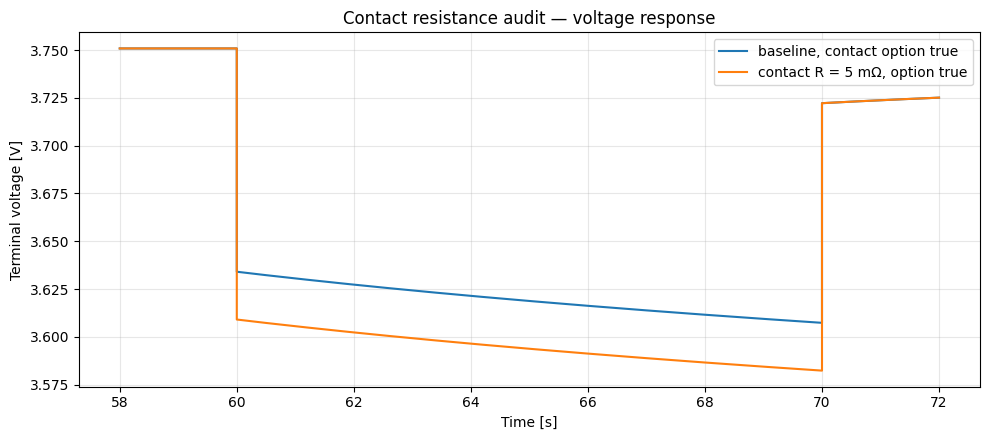

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/contact_resistance_enabled_voltage_overlay.png


In [11]:
plot_mask = (
    (merged_on["time_rel_s"] >= 58)
    & (merged_on["time_rel_s"] <= 72)
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))

ax1.plot(
    merged_on.loc[plot_mask, "time_rel_s"],
    merged_on.loc[plot_mask, "voltage_V_base_on"],
    label="baseline, contact option true",
)

ax1.plot(
    merged_on.loc[plot_mask, "time_rel_s"],
    merged_on.loc[plot_mask, "voltage_V_contact_on"],
    label="contact R = 5 mΩ, option true",
)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Terminal voltage [V]")
ax1.set_title("Contact resistance audit — voltage response")
ax1.grid(True, alpha=0.3)
ax1.legend()

fig.tight_layout()
fig_path = FIGURES / "contact_resistance_enabled_voltage_overlay.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [12]:
def extract_Ri_simple(df):
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    pulse_mask = np.abs(i) > 0.1
    pulse_idx = np.where(pulse_mask)[0]

    t_start = t[pulse_idx[0]]
    t_end = t[pulse_idx[-1]]

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)

    U_C = np.median(u[C_window])
    U_D = np.median(u[D_window])
    U_E = np.median(u[E_window])
    U_F = np.median(u[F_window])

    I_C = np.median(i[C_window])
    I_D = np.median(i[D_window])
    I_E = np.median(i[E_window])
    I_F = np.median(i[F_window])

    Ri_CD_mohm = abs((U_D - U_C) / (I_D - I_C)) * 1000
    Ri_EF_mohm = abs((U_F - U_E) / (I_F - I_E)) * 1000

    return {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "U_C_V": U_C,
        "U_D_V": U_D,
        "U_E_V": U_E,
        "U_F_V": U_F,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
    }


ri_base_on = extract_Ri_simple(df_base_on)
ri_contact_on = extract_Ri_simple(df_contact_on)

ri_compare = pd.DataFrame(
    [
        {"case": "baseline_contact_option_true", **ri_base_on},
        {"case": "contact_R_5mOhm_option_true", **ri_contact_on},
    ]
)

ri_compare["delta_Ri_CD_vs_baseline_mohm"] = (
    ri_compare["Ri_CD_mohm"] - ri_compare.loc[0, "Ri_CD_mohm"]
)

ri_compare["delta_Ri_EF_vs_baseline_mohm"] = (
    ri_compare["Ri_EF_mohm"] - ri_compare.loc[0, "Ri_EF_mohm"]
)

display(ri_compare)

,case,pulse_start_s,pulse_end_s,U_C_V,U_D_V,U_E_V,U_F_V,Ri_CD_mohm,Ri_EF_mohm,delta_Ri_CD_vs_baseline_mohm,delta_Ri_EF_vs_baseline_mohm
0,baseline_contact_option_true,60.0,70.0,3.750874,3.633146,3.60763,3.722479,23.545486,22.969868,0.0,0.0
1,contact_R_5mOhm_option_true,60.0,70.0,3.750874,3.608146,3.58263,3.722479,28.545486,27.969868,5.0,5.0


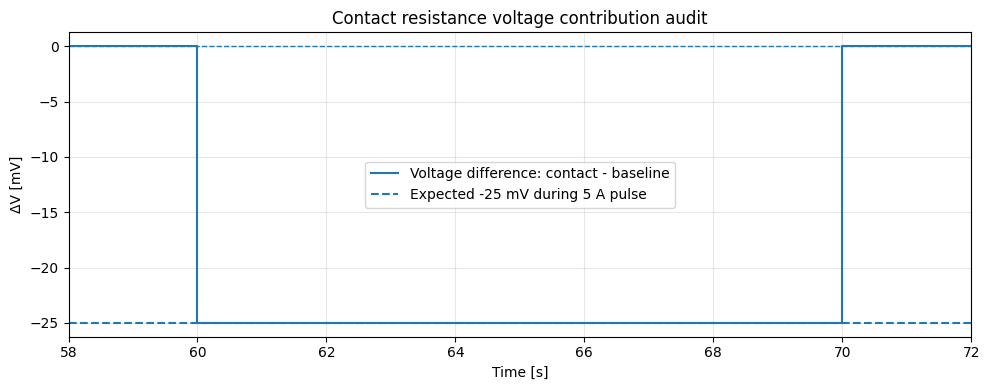

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/contact_resistance_enabled_voltage_difference.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    merged_on["time_rel_s"],
    merged_on["dV_contact_minus_base_mV"],
    label="Voltage difference: contact - baseline",
)

ax.axhline(-25, linestyle="--", label="Expected -25 mV during 5 A pulse")
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlim(58, 72)
ax.set_xlabel("Time [s]")
ax.set_ylabel("ΔV [mV]")
ax.set_title("Contact resistance voltage contribution audit")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "contact_resistance_enabled_voltage_difference.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

# Notebook 04 Conclusion

This notebook audits why `Contact resistance [Ohm] = 0.005` produced no observable response in the previous Tier-0 sanity scan.

The audit confirms that the parameter `Contact resistance [Ohm]` exists in the Chen2020 parameter set, and that the model variable `Contact overpotential [V]` is available. However, in the default DFN configuration, the model option is:

`"contact resistance": "false"`

Under this default configuration, the contact overpotential remains zero and the terminal voltage response is unchanged, even when `Contact resistance [Ohm]` is set to 5 mΩ.

When the DFN model is instantiated with:

`pybamm.lithium_ion.DFN({"contact resistance": "true"})`

and `Contact resistance [Ohm] = 0.005`, the model produces a contact overpotential of 25 mV during the 5 A discharge pulse.

This matches the expected ohmic contribution:

`ΔU = I · R = 5 A × 0.005 Ω = 25 mV`

The extracted short-window resistance increases by exactly 5 mΩ:

- `Ri_CD: +5.000 mΩ`
- `Ri_EF: +5.000 mΩ`

Therefore, the lack of response in Notebook 03 was caused by a disabled model option, not by the observable extraction chain.

## Implication for future scans

Future Tier-0 and Phase-B perturbation scans must instantiate the DFN model with `"contact resistance": "true"` when evaluating contact-resistance growth as an ohmic degradation pathway.

## Interpretation boundary

This notebook does not claim that contact resistance dominates aging behavior. It only establishes that contact resistance is observable in the current PyBaMM workflow when the corresponding model option is explicitly enabled.